In [1]:
import pandas as pd
import os

folder_path = "public_data_test/track_a/train"
dataframes = []


for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        df.columns = [col.lower() for col in df.columns]
        dataframes.append(df)


combined_df = pd.concat(dataframes, ignore_index=True)

if len(combined_df.columns) >= 6:
    for col in combined_df.columns[-6:]:
        combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce').fillna(0).astype(int)

df = combined_df.iloc[:,1:]

In [2]:
df

,text,anger,disgust,fear,joy,sadness,surprise
0,简单说就是有阳性病例，查密切接触者时发现了一些很久没有做核酸的人，还陆续被查出阳性，只能隔离...,0,0,0,0,0,0
1,运镜也好牛 第一次在电视剧中如此密集地感受到 镜头语言 编剧音乐演技都在线,0,0,0,1,0,0
2,现在任何事情只要沾上互联网都会变得不幸。因为脑残太多，总是喜欢毁掉一切美好的事物。,1,0,0,0,0,0
3,如果能在每个黄昏睡醒后 吃到一堆自己喜欢的东西就好了 看着逐渐被黑暗统治的世界 要下一口炸鸡...,0,0,0,1,0,0
4,四五岁时候，我天天在家哭唧唧“我要去上学，为什么不让我去学校”。那时候农村上学晚，也没有太严...,0,0,0,0,0,0
...,...,...,...,...,...,...,...
65093,Nk’umugore ahora atekereza ko umugabo ashobora...,0,0,1,0,0,0
65094,@<username> Iyo uri mwiza uba uri mwiza kbsa,0,0,0,0,0,0
65095,@<username> @<username> @<username> @<username...,0,0,0,0,0,0
65096,@<username> Happy birthday to you Aissa. Imana...,0,0,0,1,0,0


In [3]:
ID2LABEL = {}
LABEL2ID = {}

for idx,label in enumerate(df.columns):
    if label in ['text'] or label in ['id']:
        continue

    ID2LABEL[idx-1] = label
    LABEL2ID[label] = idx-1

print(f"ID2LABEL: {ID2LABEL}")
print(f"LABEL2ID: {LABEL2ID}")

ID2LABEL: {0: 'anger', 1: 'disgust', 2: 'fear', 3: 'joy', 4: 'sadness', 5: 'surprise'}
LABEL2ID: {'anger': 0, 'disgust': 1, 'fear': 2, 'joy': 3, 'sadness': 4, 'surprise': 5}


In [4]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

# X = df['text']
# y = df.drop('text', axis=1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

# Combine them into a DatasetDict
dataset_dict = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

# Print information about the DatasetDict
print(dataset_dict)

ModuleNotFoundError: No module named 'datasets'

In [ ]:
# get emotion counts by split type
split_types = list(dataset_dict.keys())
emotion_split_counts = {}

for label in LABEL2ID:
    for split_type in split_types:
        if label not in emotion_split_counts:
            emotion_split_counts[label] = []
        emotion_split_counts[label].append(sum(dataset_dict[split_type][label]))

print(f"SPLIT_TYPES: {split_types}")
print(f"EMOTION_SPLIT_COUNTS: {emotion_split_counts}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

LABEL2COLOR = {
    'anger': 'red',
    'disgust': 'green',
    'fear':'purple',
    'joy': 'yellow',
    'sadness': 'blue',
    'surprise': 'pink',
}

x = np.arange(len(split_types))
width = 0.15
multiplier = 0

fig, ax = plt.subplots()
for label, counts in emotion_split_counts.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, counts, width, label=label, color=LABEL2COLOR[label])
    ax.bar_label(rects, label_type='edge')
    multiplier += 1

ax.set_xlabel('Split Type')
ax.set_ylabel('Count')
ax.set_title('Emotion Counts by Split Type')
ax.set_xticks(x + width, split_types)
ax.legend()
plt.show()

In [ ]:
emotion_counts = {}
for label in LABEL2ID:
    for split_type in dataset_dict.keys():
        emotion_counts[label] = emotion_counts.get(label,0)+sum(dataset_dict[split_type][label])

print(f"EMOTION_COUNTS: {emotion_counts}")

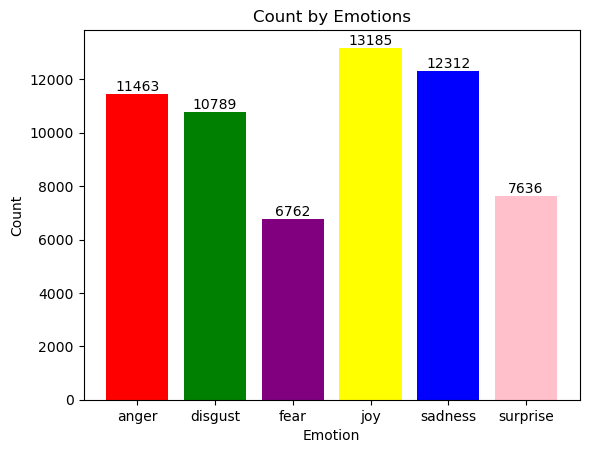

In [11]:
# plot bar graph with total emotion counts
fig, ax = plt.subplots()
bar_container = ax.bar(emotion_counts.keys(), emotion_counts.values(), color=LABEL2COLOR.values())
ax.bar_label(bar_container, label_type='edge')
ax.set_xlabel('Emotion')
ax.set_ylabel('Count')
ax.set_title('Count by Emotions')
plt.show()

# Preprocessing

In [13]:
def preprocess(batch):
    # rename column
    # batch['ID'] = batch['id']
    batch['Tweet'] = batch['text']

    # get one-hot encoded labels for each example in batch
    # for example: anger and sadness = vector of [1,0,0,0,1]
    batch['labels'] = [[float(batch[label][i]) for label in LABEL2ID] for i in range(len(batch['Tweet']))]
    return batch

preprocessed_datasets = dataset_dict.map(preprocess, batched=True, remove_columns=dataset_dict['train'].column_names)
preprocessed_datasets

Parameter 'function'=<function preprocess at 0x000001C6FC27E980> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


  0%|          | 0/53 [00:00<?, ?ba/s]

  0%|          | 0/14 [00:00<?, ?ba/s]

DatasetDict({
    train: Dataset({
        features: ['Tweet', 'labels'],
        num_rows: 52078
    })
    test: Dataset({
        features: ['Tweet', 'labels'],
        num_rows: 13020
    })
})

In [16]:
preprocessed_datasets['train'][2]

{'Tweet': 'Поверніть мене до піанобоя, пліз',
 'labels': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}

# Data Tokenization

In [20]:
from transformers import AutoTokenizer

CHECKPOINT = 'j-hartmann/emotion-english-distilroberta-base'
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)
tokenizer

RobertaTokenizerFast(name_or_path='j-hartmann/emotion-english-distilroberta-base', vocab_size=50265, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50264: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}

In [22]:
# tokenize out datasets with truncation
tokenized_datasets = preprocessed_datasets.map(lambda batch: tokenizer(batch['Tweet'], padding="max_length", truncation=True, max_length=512), batched=True, remove_columns=['Tweet'])
tokenized_datasets

  0%|          | 0/53 [00:00<?, ?ba/s]

  0%|          | 0/14 [00:00<?, ?ba/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 52078
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 13020
    })
})

In [ ]:
tokenized_datasets['train'][:1]

# Model Training

In [ ]:
# set seed for reproducibility
import torch

SEED = 42
torch.manual_seed(SEED)

In [ ]:
# let's clone a model and finetune as a multi-label classification problem
from transformers import AutoModelForSequenceClassification

# source: https://huggingface.co/distilbert-base-uncased
model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT, problem_type='multi_label_classification', num_labels=len(LABEL2ID), id2label=ID2LABEL, label2id=LABEL2ID)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# this function calculates accuracy per label in a prediction instead of per prediction
def samples_accuracy_score(y_true, y_pred):
    return np.sum(y_true==y_pred) / y_true.size

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    # we sigmoid all logits for multilabel metrics
    predictions = torch.nn.functional.sigmoid(torch.Tensor(logits))
    # we set threshold to 0.50 to classify positive >= 0.50 and negative < 0.50
    predictions = (predictions >= 0.50).int().numpy()
    # overall accuracy measures accuracy of each true label list and prediction list
    overall_accuracy = accuracy_score(labels, predictions)
    # sample accuracy measures accuracy of each true label in a true label list and prediction in prediction list
    samples_accuracy = samples_accuracy_score(labels, predictions)
    # overall f1 measures macro f1 of each true label list and prediction list, ignoring zero division warnings
    overall_f1 = f1_score(labels, predictions, average='macro', zero_division=0)
    # samples f1 measures f1 of each true label in a true label list and prediction in prediction list, ignoring zero division warnings
    samples_f1 = f1_score(labels, predictions, average='samples', zero_division=0)
    return {
        'overall_accuracy': overall_accuracy,
        'samples_accuracy': samples_accuracy,
        'overall_f1': overall_f1,
        'samples_f1': samples_f1,
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    seed=SEED,                          # seed for reproducibility
    output_dir='results',               # output directory to store epoch checkpoints
    num_train_epochs=5,                 # number of training epochs
    optim='adamw_torch',                # default optimizer as AdamW
    per_device_train_batch_size=32,     # 32 train batch size to speed up training
    per_device_eval_batch_size=32,      # 32 eval batch size to speed up evaluation
    evaluation_strategy='epoch',        # set evaluation strategy to each epoch instead of default 500 steps
    save_strategy='epoch',              # set saving of model strategy to each epoch instead of default 500 steps
    load_best_model_at_end=True,        # load the best model with lowest validation loss
    report_to='none',                   # suppress third-party logging
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

In [ ]:
# let's see what an unfine-tuned bert can do
trainer.evaluate(tokenized_datasets['test'])

In [ ]:
# let's fine-tune bert as a multilabel problem
trainer.train()

In [ ]:
# let's see what a finetuned bert can do
trainer.evaluate(tokenized_datasets['test'])

In [ ]:
predictions, label_ids, metrics = trainer.predict(tokenized_datasets['test'])

In [ ]:
sigmoid = torch.sigmoid(torch.tensor(predictions))

In [ ]:
predicted_labels = sigmoid.numpy()

In [ ]:
threshold = 0.5
predicted_labels_binary = (predicted_labels > threshold).astype(int)

In [ ]:
for idx, (pred, true_label) in enumerate(zip(predicted_labels_binary, label_ids)):
    print(f"Row {idx}: Predicted labels = {pred}, True labels = {true_label}")

In [ ]:
import pandas as pd
import os

folder_path = "public_data_test/track_a/dev"
dataframes = []


for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        df.columns = [col.lower() for col in df.columns]
        dataframes.append(df)


combined_df = pd.concat(dataframes, ignore_index=True)

if len(combined_df.columns) >= 6:
    for col in combined_df.columns[-6:]:
        combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce').fillna(0).astype(int)

df = combined_df.iloc[:,1:]

In [ ]:
trainer.save_model("model")

In [ ]:
from transformers import pipeline
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import torch
import os
import pandas as pd

SEED = 42
torch.manual_seed(SEED)

CHECKPOINT = 'bert-base-multilingual-cased'
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

model = AutoModelForSequenceClassification.from_pretrained("model")
twitter_emotion_multilabel_classifier = pipeline(task='text-classification', model=model, tokenizer=tokenizer, device=torch.cuda.current_device(), top_k=None)

In [ ]:
!pip install textblob
!pip install sentencepiece
!pip install googletrans
!pip install translators

In [ ]:
from transformers import pipeline
emotion_english_pipeline = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k=None, device=0)


In [27]:
import asyncio
import time
from googletrans import Translator
import translators as ts

async def detect_language_google(text):
    max_retries = 3
    async with Translator() as translator:
        retries = 0
        while retries < max_retries:
            try:
                result = await translator.detect(text)
                print(result, text)
                return str(result.lang)
            except Exception as e:
                retries += 1
                print(f"Error: {e}. Retrying {retries}/{max_retries}...")
                time.sleep(600)  # Optional: Add delay between retries
                
        return 'unknown'
        
def emotion_english_classifier(text):   
    results = emotion_english_pipeline(text)
    emotions = {}
    for result in results[0]:
        emotions[result['label']] = result['score']

    emo_list = []
    for emo in emotions:
      if emotions[emo] > 0.5:
        emo_list.append(emo)

    return ','.join(emo_list)

def translate_first(q_text):
    success = False
    retries = 0
    while not success or retries < 3:
        try:
            translated = ts.translate_text(q_text, translator='google', from_language='auto', to_language='en')
            print(q_text, translated, detect_language(translated) == 'en')
            if (detect_language(translated) != 'en'):
                translated = ts.translate_text(q_text, translator='bing', from_language='auto', to_language='en')
                print(q_text, translated)
                if (detect_language(translated) != 'en'):
                    translated = ts.translate_text(q_text, translator='alibaba', from_language='auto', to_language='en')
                    print(q_text, translated)
                    success = True
                    retries = 99
                else:
                    success = True
                    retries = 99
            else:
                success = True
                retries = 99
        except:
            time.sleep(300)
            retries += 1
        
    return translated
    

async def detect_and_classify(text):
    async with Translator() as translator:
        result = await translator.detect(text)
        if str(result.lang) != 'en':
            text = translate_first(text)
            time.sleep(5)
            return emotion_english_classifier(text)

async def detect_languages_in_combined_df(df):
  df_to_update = df[df['lang'] == 'unknown'].copy()
  df_to_update['lang'] = await asyncio.gather(*(detect_language_google(v) for v in df_to_update['text']))
  df.loc[df_to_update.index, 'lang'] = df_to_update['lang']



In [28]:
#async def detect_languages_in_df():
#  df['lang'] = await asyncio.gather(*(detect_language_google(v) for v in df['text']))

#await detect_languages_in_df()

In [29]:
result = await detect_language_google(u'ኣብ ኩዊናት ልምዓት ስርዓት ብልጽግና ጽቡቕ ጉርብትና የለን። እንትርፎ ጥፍኣት ጥሜትን ዕርቃንን ምግሃስ ስብኣዊ መሰልን። ካብ ኩዊናት ዝረብሑ ኣጽዋር ዘምርቱን ዝሸ')
result

Detected(lang=ti, confidence=1) ኣብ ኩዊናት ልምዓት ስርዓት ብልጽግና ጽቡቕ ጉርብትና የለን። እንትርፎ ጥፍኣት ጥሜትን ዕርቃንን ምግሃስ ስብኣዊ መሰልን። ካብ ኩዊናት ዝረብሑ ኣጽዋር ዘምርቱን ዝሸ


'ti'

In [35]:
async with Translator() as translator:
    result = await translator.translate('안녕하세요.', dest='ja')
    print(result)

Translated(src=ko, dest=ja, text=こんにちは。, pronunciation=Kon'nichiwa., extra_data="{'translat...")


In [93]:
import os
CHATAI_API_KEY = os.environ.get('CHATAI_API_KEY')
CHATAI_API_KEY

'sk-57d9552372474c959be9c0ad55544f36'

In [39]:
import requests
import json

PREFIX_PROMPT = """Classify emotion from the given text into one or more: Joy, Fear, Anger, Sadness, Disgust, Neutral, Surprise.
The output is only the multilabel classes (Joy, Fear, Anger, Sadness, Disgust, Neutral, Surprise) and separated by a comma. 
Do not use other unspecified classes. Do not output the reasoning statement or unnecessary sentences. 
If you don't know or unsure, translate into English first. 
If you cannot translate directly to English, translate it first to another known language, and from that another known language to English.
The translation can be transitive more than one languages."""


def emotion_llama_classifier(message):
    url = 'https://api-llm.ub.ac.id/api/chat/completions'
    headers = {
        'Authorization': f'Bearer {CHATAI_API_KEY}',
        'Content-Type': 'application/json'
    }
    payload = {
        'model': 'llama3.3:latest',
        'messages': [{'role': 'user', 'content': PREFIX_PROMPT + " The text is:""" + message}]
    }
    #print(headers, payload)
    response = requests.post(url, headers=headers, json=payload)
    #print(response)
    response_json = response.json()
    return response_json['choices'][0]['message']['content'].lower()

In [41]:
import requests
import json
import re
def emotion_deepseek_classifier(message):
    url = 'https://api-llm.ub.ac.id/api/chat/completions'
    headers = {
        'Authorization': f'Bearer {CHATAI_API_KEY}',
        'Content-Type': 'application/json'
    }
    payload = {
        'model': 'deepseek-r1:70b',
        'messages': [{'role': 'user', 'content': """Classify emotion from the given text into one or more: Joy, Fear, Anger, Sadness, Disgust, Neutral, Surprise.
The output is only the multilabel classes and separated by a comma. Do not output the reasoning statement or unnecessary sentences. Do not include anything in <think></think> tag.
If you don't know or unsure, translate into English first. The text is:""" + message}]

    
    }
    #print(headers, payload)
    response = requests.post(url, headers=headers, json=payload)
    print(response)
    response_json = response.json()
    resp_text = response_json['choices'][0]['message']['content'].lower()
    classes = re.findall(r'<think>.*?<\/think>\n{1,}(.*)', resp_text, re.MULTILINE | re.IGNORECASE | re.S)
    return classes[0]

In [43]:
emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
def classify_emotions(tweet):
    # Run the pipeline on each tweet and get the labels
    #results = twitter_emotion_multilabel_classifier(tweet)
    results = emotion_llama_classifier(tweet)
    print(tweet)

    # Threshold for classification
    threshold = 0.5

    # Initialize binary labels with 0s for each emotion
    binary_labels = {emotion: 0 for emotion in emotion_labels}
    
    # Process the results from the pipeline
    for prediction in results[0]:
        label = prediction['label'].lower()  # Ensure lowercase to match the emotion labels
        score = prediction['score']

        # If the label score exceeds the threshold, set the corresponding emotion to 1
        if label in binary_labels and score > threshold:
            binary_labels[label] = 1
    print([binary_labels[emotion] for emotion in emotion_labels])
    # Return the binary labels as a list

    return [binary_labels[emotion] for emotion in emotion_labels]

def classify_emotions_chat(tweet):
    # Run the pipeline on each tweet and get the labels
    #results = twitter_emotion_multilabel_classifier(tweet)
    results = emotion_llama_classifier(tweet)
    print(tweet)

    # Threshold for classification
#    threshold = 0.5

    # Initialize binary labels with 0s for each emotion
    binary_labels = {emotion: 0 for emotion in emotion_labels}
    #print(binary_labels)
    # Process the results from the pipeline
    print("PREDICTIONS", results)
    
    for prediction in results.split(','):
        label = prediction.lower().strip()  # Ensure lowercase to match the emotion labels
        #score = prediction['score']

        # If the label score exceeds the threshold, set the corresponding emotion to 1
        if label in binary_labels: # and score > threshold:
            #print(">>prediction: ", label, binary_labels)
            binary_labels[label] = 1

    #print([binary_labels[emotion] for emotion in emotion_labels])
    # Return the binary labels as a list

    #return [binary_labels[emotion] for emotion in emotion_labels]
    return binary_labels

In [45]:
existing_files_trans = []
prediction_path = r'public_data_test/track_a/dev_trans/'
for file in os.listdir(prediction_path):
    if file.endswith(".csv"):# and file=="vmw.csv":
        file = file.replace('pred_', '')
        existing_files_trans.append(file)
existing_files_trans

[]

In [83]:
import asyncio
import time
import traceback 

from googletrans import Translator

folder_path = "public_data_test/track_a/dev"
dataframes = []
import time

def tokenize_text(text):
    # Tokenize the text with truncation and padding to 512 tokens (if needed)
    encoding = tokenizer(text, truncation=True, padding='max_length', max_length=512, return_tensors="pt")
    return encoding

# Wrapper function to handle retries
def apply_with_retries(row, func, max_retries=3):
    retries = 0
    while retries < max_retries:
        try:
            return func(row)
        except Exception as e:
            retries += 1
            print(f"Error: {e}. Retrying {retries}/{max_retries}...")
            time.sleep(300)  # Optional: Add delay between retries
    print(f"Failed after {max_retries} retries for row: {row.to_dict()}")
    return ''  # Return a default value or handle as needed

# Apply the function to the DataFrame with timeout and retry
#df['A'] = df['A'].apply(lambda x: apply_with_timeout(x))

from collections import Counter

def max_occurrence_string(arr):
    if not arr:
        return None  # Return None if the array is empty
    
    counter = Counter(arr)
    max_occurrence = max(counter.values())
    most_common_strings = [string for string, count in counter.items() if count == max_occurrence]
    
    return most_common_strings

async def append_to_list(data, the_list):
    the_list.append(str(data.lang))
    return the_list
    
async def detect_languages_in_df(df):
    langs = []
    # langs = await append_to_list(await translator.detect(df['text'].iloc[0]), langs)    
    # langs = await append_to_list(await translator.detect(df['text'].iloc[1]), langs)
    # langs = await append_to_list(await translator.detect(df['text'].iloc[2]), langs)
    langs.append(await detect_language_google(df['text'].iloc[0]))
    langs.append(await detect_language_google(df['text'].iloc[1]))
    langs.append(await detect_language_google(df['text'].iloc[2]))
    langs.append(await detect_language_google(df['text'].iloc[3]))
    langs.append(await detect_language_google(df['text'].iloc[4]))
    return langs
    #df['lang'] = lang
    #df['lang'] = await asyncio.gather(*(detect_language_google(v) for v in df['text']))



In [87]:
for file in os.listdir(folder_path):
    if file.endswith(".csv") and file=="vmw.csv":
        if file in existing_files_trans:
            continue
            
        success = False
        #while not success:
        try:
            file_path = os.path.join(folder_path, file)
            print(file)
            df = pd.read_csv(file_path)
            
            langs = await detect_languages_in_df(df)
            lang = max_occurrence_string(langs)
            print(lang)
            df['lang'] = lang[0]

            df.to_csv(f'public_data_test/track_a/dev_trans/{file}', index=False)
            success = True
        except :
            success = False
            traceback.print_exc() 
            #time.sleep(300)
                

vmw.csv
Detected(lang=lg, confidence=0.5293045) Maputu onimutholathola mpatthani wiira amwaakihe LAM, namawehaweha onihimya wiira onikhala ntoko onwurya "axipiriina'.
Detected(lang=ny, confidence=0.30674884) Maweheriwa a miteko sa Mpanko ootapanyeya mMosampikhi
Detected(lang=rw, confidence=0.71596044) EUA ohinteererya mukwaha wa  Blinken oorowa Oxiina nookhumelela epalawu mixiteriyoosu Vamontaana
Detected(lang=te, confidence=0.5220002) Maniniixituru mayili ookhalayi a STF aalakela omuthanla Lula
Detected(lang=lg, confidence=0.9050686) Braziili Oniira taata wa Ekoopa ya Olumwenku nuuloliya woowereya.
['lg']


In [89]:
df

,id,text,anger,disgust,fear,joy,sadness,surprise,lang
0,vmw_dev_track_a_00001,Maputu onimutholathola mpatthani wiira amwaaki...,0,0,0,0,0,0,lg
1,vmw_dev_track_a_00002,Maweheriwa a miteko sa Mpanko ootapanyeya mMos...,0,0,0,0,0,0,lg
2,vmw_dev_track_a_00003,EUA ohinteererya mukwaha wa Blinken oorowa Ox...,0,0,0,0,0,1,lg
3,vmw_dev_track_a_00004,Maniniixituru mayili ookhalayi a STF aalakela ...,0,0,0,0,0,1,lg
4,vmw_dev_track_a_00005,Braziili Oniira taata wa Ekoopa ya Olumwenku n...,0,0,0,0,1,0,lg
...,...,...,...,...,...,...,...,...,...
253,vmw_dev_track_a_00254,Kuveerunu a Kaapu Veerete ohoohiya mattee...,0,0,0,0,0,0,lg
254,vmw_dev_track_a_00255,Top Ten Amerikaano: Jermaine Dupri mphironi wo...,0,0,0,0,0,0,lg
255,vmw_dev_track_a_00256,Mantiixina aniirwa yoopopihaka woopola oTuraat...,1,0,0,0,0,0,lg
256,vmw_dev_track_a_00257,Materoriixita a Opariixi aatthukwelasiwa Opeel...,0,0,0,1,0,0,lg


In [ ]:
existing_files = []
prediction_path = r'public_data_test/track_a/pred/'
for file in os.listdir(prediction_path):
    if file.endswith(".csv"):# and file=="vmw.csv":
        file = file.replace('pred_', '')
        existing_files.append(file)
existing_files

In [ ]:
folder_path = "public_data_test/track_a/dev"
dataframes = []
import time

def tokenize_text(text):
    # Tokenize the text with truncation and padding to 512 tokens (if needed)
    encoding = tokenizer(text, truncation=True, padding='max_length', max_length=512, return_tensors="pt")
    return encoding

#from retrying import retry
#from concurrent.futures import ThreadPoolExecutor, TimeoutError

# Define the function to apply
# def classify_with_retry(x):
#     # Simulate a function that might take time
#     return classify_emotions_chat(x)

# # Define a retry decorator with a timeout
# @retry(stop_max_attempt_number=3, wait_fixed=2000)
# def apply_with_timeout(row, timeout=1):
#     with ThreadPoolExecutor() as executor:
#         future = executor.submit(classify_with_retry, row)
#         try:
#             result = future.result(timeout=timeout)
#             return result
#         except TimeoutError:
#             raise Exception("Function timed out")

# Sample function to apply
# def example_function(row):
#     # Simulating an error for demonstration
#     if row['A'] == 2:
#         raise ValueError("An error occurred with row A=2")
#     return row['A'] + row['B']

# Wrapper function to handle retries
def apply_with_retries(row, func, max_retries=3):
    retries = 0
    while retries < max_retries:
        try:
            return func(row)
        except Exception as e:
            retries += 1
            print(f"Error: {e}. Retrying {retries}/{max_retries}...")
            time.sleep(300)  # Optional: Add delay between retries
    print(f"Failed after {max_retries} retries for row: {row.to_dict()}")
    return ''  # Return a default value or handle as needed

# Apply the function to the DataFrame with timeout and retry
#df['A'] = df['A'].apply(lambda x: apply_with_timeout(x))

for file in os.listdir(folder_path):
    if file.endswith(".csv"): and file=="vmw.csv":
        if file in existing_files:
            continue
        success = False
        while not success:
            try:
                file_path = os.path.join(folder_path, file)
                print(file)
                df = pd.read_csv(file_path)
                column_names = df.columns
                print("before",df.columns)
                df.drop(columns=df.columns[2:], inplace=True)
        
                #df['text'] = df['text'].apply(lambda tweet: tokenize_text(tweet))
                
                
                df[emotion_labels] = pd.DataFrame(df['text'].apply(lambda tweet: apply_with_retries(tweet, classify_emotions_chat)).to_list(), index=df.index)
                
                print("before",df.columns)
        
                # df.columns = [col.capitalize() if idx >= 2 else col for idx, col in enumerate(df.columns)]
                df = df[column_names]
                df.drop(columns="text", inplace=True)
                print("after",df.columns)
                df.to_csv(f'public_data_test/track_a/pred/pred_{file}', index=False)
                success = True
            except:
                success = False
                time.sleep(300)
                

In [ ]:
folder_path = "public_data_dev/track_a/dev"
dataframes = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        print(file)
        df = pd.read_csv(file_path)
        column_names = df.columns
        print("before",df.columns)
        df.drop(columns=df.columns[2:], inplace=True)

        # df[emotion_labels] = pd.DataFrame(df['text'].apply(lambda tweet: classify_emotions(tweet)).to_list(), index=df.index)
        print(pd.DataFrame(df['text'].apply(lambda tweet: classify_emotions(tweet)).to_list(), index=df.index))
        print("before",df.columns)

        # df.columns = [col.capitalize() if idx >= 2 else col for idx, col in enumerate(df.columns)]
        df = df[column_names]
        df.drop(columns="text", inplace=True)
        print("after",df.columns)
        df.to_csv(f'public_data_dev/track_a/pred/pred_{file}', index=False)

In [ ]:
anger_tweet = """
We should lock the door and scream that curse word we know.
"""

#twitter_emotion_multilabel_classifier(anger_tweet)

In [ ]:
disgust_tweet = """
You know what else barely touches the ground? Stray dogs, toenail clippings, road kill, hippies, dung beetles...
"""

#twitter_emotion_multilabel_classifier(disgust_tweet)

In [ ]:
response = emotion_llama_classifier(anger_tweet)

In [ ]:
response

In [ ]:
classify_emotions_chat(anger_tweet)

In [ ]:
classify_emotions_chat("Selenskiy = reichster Bettler")

In [ ]:
emotion_deepseek_classifier(anger_tweet)